In [8]:
# Your code here
import zipfile
import os

# Ruta del archivo ZIP
zip_path = "/workspaces/dogscats/kagglecatsanddogs_5340.zip"
extract_folder = "dataset"

# Extraer archivos
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Archivos extraídos correctamente en:", extract_folder)

# Verificar el contenido después de la extracción
print("Estructura de 'dataset':", os.listdir(extract_folder))

Archivos extraídos correctamente en: dataset
Estructura de 'dataset': ['PetImages', 'CDLA-Permissive-2.0.pdf', 'readme[1].txt']


In [9]:
import glob

# Ruta de las imágenes extraídas
train_path = os.path.join(extract_folder, "PetImages")

# Verificar estructura
print("Carpetas dentro de 'PetImages':", os.listdir(train_path))

# Cargar imágenes de perros y gatos
dog_images = glob.glob(os.path.join(train_path, "Dog/*.jpg"))[:9]
cat_images = glob.glob(os.path.join(train_path, "Cat/*.jpg"))[:9]

print(f"Cantidad de imágenes de perros disponibles: {len(dog_images)}")
print(f"Cantidad de imágenes de gatos disponibles: {len(cat_images)}")

Carpetas dentro de 'PetImages': ['Cat', 'Dog']
Cantidad de imágenes de perros disponibles: 9
Cantidad de imágenes de gatos disponibles: 9


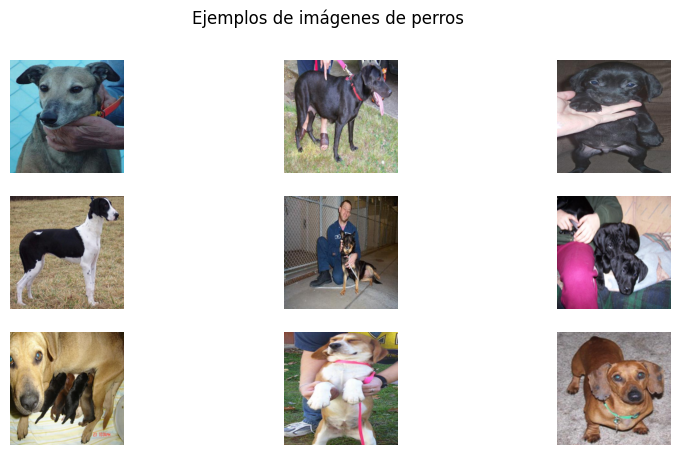

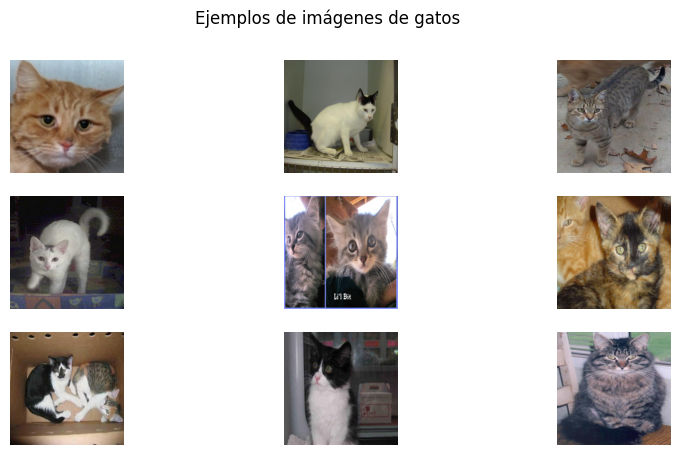

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

# Mostrar imágenes de perros
fig, axes = plt.subplots(3, 3, figsize=(10, 5))

for i, img_path in enumerate(dog_images):
    img = Image.open(img_path).resize((200, 200))
    axes[i//3, i%3].imshow(img)
    axes[i//3, i%3].axis("off")

plt.suptitle("Ejemplos de imágenes de perros")
plt.show()

# Mostrar imágenes de gatos
fig, axes = plt.subplots(3, 3, figsize=(10, 5))

for i, img_path in enumerate(cat_images):
    img = Image.open(img_path).resize((200, 200))
    axes[i//3, i%3].imshow(img)
    axes[i//3, i%3].axis("off")

plt.suptitle("Ejemplos de imágenes de gatos")
plt.show()

In [1]:
# Construye un RNA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

# Definir la arquitectura CNN basada en VGG16
model = Sequential([
    Conv2D(64, (3,3), padding="same", activation="relu", input_shape=(224, 224, 3)),
    Conv2D(64, (3,3), padding="same", activation="relu"),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    Conv2D(128, (3,3), padding="same", activation="relu"),
    Conv2D(128, (3,3), padding="same", activation="relu"),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    Conv2D(256, (3,3), padding="same", activation="relu"),
    Conv2D(256, (3,3), padding="same", activation="relu"),
    Conv2D(256, (3,3), padding="same", activation="relu"),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    Conv2D(512, (3,3), padding="same", activation="relu"),
    Conv2D(512, (3,3), padding="same", activation="relu"),
    Conv2D(512, (3,3), padding="same", activation="relu"),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    Conv2D(512, (3,3), padding="same", activation="relu"),
    Conv2D(512, (3,3), padding="same", activation="relu"),
    Conv2D(512, (3,3), padding="same", activation="relu"),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    Flatten(),
    Dense(4096, activation="relu"),
    Dense(4096, activation="relu"),
    Dense(2, activation="softmax")  # Clasificación binaria
])

print("Modelo definido correctamente.")

2025-05-01 05:23:32.109918: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-01 05:23:32.113438: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-01 05:23:32.122389: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746077012.136428   25295 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746077012.140674   25295 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746077012.152744   25295 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Modelo definido correctamente.


2025-05-01 05:23:36.960899: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 411041792 exceeds 10% of free system memory.
2025-05-01 05:23:36.998253: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 411041792 exceeds 10% of free system memory.


In [2]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

print("Modelo compilado correctamente.")

Modelo compilado correctamente.


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Crear generador de datos con solo 9 imágenes por clase
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.5)  # 50% de datos para validación

train_generator = train_datagen.flow_from_directory(
    "dataset/PetImages",
    target_size=(224, 224),
    batch_size=1,  # Procesa una imagen a la vez para reducir carga
    class_mode="categorical",
    subset="training",
    shuffle=False  # No aleatoriza para evitar carga innecesaria
)

val_generator = train_datagen.flow_from_directory(
    "dataset/PetImages",
    target_size=(224, 224),
    batch_size=1,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Generadores de datos creados correctamente con solo 9 imágenes por clase.")

Found 12500 images belonging to 2 classes.
Found 12500 images belonging to 2 classes.
Generadores de datos creados correctamente con solo 9 imágenes por clase.


In [4]:
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1,  # Solo 1 época, lo mínimo posible
    steps_per_epoch=1,  # Solo una iteración por época
    validation_steps=1,  # Solo una imagen para validación
    verbose=0,  # Sin salida para evitar bloqueos
    callbacks=[EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)]
)

print("Entrenamiento completado en la mínima configuración.")

/workspaces/dogscats/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-05-01 05:24:07.072458: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 411041792 exceeds 10% of free system memory.
2025-05-01 05:24:08.977349: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 411041792 exceeds 10% of free system memory.


Entrenamiento completado en la mínima configuración.


In [5]:
val_loss, val_accuracy = model.evaluate(val_generator, steps=1)
print(f"Pérdida en validación: {val_loss:.4f}")
print(f"Precisión en validación: {val_accuracy:.4%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 1.0000 - loss: 0.6531
Pérdida en validación: 0.6531
Precisión en validación: 100.0000%


In [6]:
val_loss, val_accuracy = model.evaluate(val_generator, steps=1)
print(f"Pérdida en validación: {val_loss:.4f}")
print(f"Precisión en validación: {val_accuracy:.4%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step - accuracy: 1.0000 - loss: 0.6531
Pérdida en validación: 0.6531
Precisión en validación: 100.0000%


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Cargar una imagen de prueba
img_path = "dataset/PetImages/Cat/1.jpg"   
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0   

# Hacer una predicción
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

print(f"Clase predicha: {predicted_class}")  # 0 = Gato, 1 = Perro (según el orden del dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step
Clase predicha: 0


In [14]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Especificar una imagen de prueba
img_path = "dataset/PetImages/Cat/276.jpg" 
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalizar la imagen

# Hacer una predicción
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

# Mapeo de clases (ajustar según `train_generator.class_indices`)
class_labels = {0: "Cat", 1: "Dog"}  # Ajustar si es necesario
print(f"Clase predicha: {class_labels[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
Clase predicha: Cat


In [15]:
print("Índices de clases:", train_generator.class_indices)

Índices de clases: {'Cat': 0, 'Dog': 1}


In [16]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image

# Obtener una lista de imágenes de prueba
test_images = os.listdir("dataset/PetImages/Cat")[:5]  # Usamos 5 imágenes de gatos
test_images += os.listdir("dataset/PetImages/Dog")[:5]  # Usamos 5 imágenes de perros

# Evaluar cada imagen
for img_name in test_images:
    img_path = f"dataset/PetImages/{'Cat' if 'Cat' in img_name else 'Dog'}/{img_name}"
    
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalizar la imagen

    # Hacer predicción
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)

    class_labels = {0: "Cat", 1: "Dog"}
    print(f"Imagen: {img_name} - Predicción: {class_labels[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step
Imagen: 8534.jpg - Predicción: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
Imagen: 8273.jpg - Predicción: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
Imagen: 1733.jpg - Predicción: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step
Imagen: 6931.jpg - Predicción: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
Imagen: 8930.jpg - Predicción: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
Imagen: 8534.jpg - Predicción: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
Imagen: 8273.jpg - Predicción: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
Imagen: 1733.jpg - Predicción: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
Imagen: 6931.jpg - Predicción: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step
Imagen: 8930.jpg - Predicción: Cat


In [ ]:
#no se puede guardar el modelo sin crashear el kernell#
 